<a href="https://colab.research.google.com/github/Halimahiyanda/Automobile-Sales/blob/main/Automobile_Sales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Automobile Sales Analysis during Recession and Non-Recession Periods


Scenario
In this assignment you will be tasked with creating plots which answer questions for analysing "automobile_sales" data to understand the historical trends in automobile sales during recession periods.
recession period 1 - year 1980
recession period 2 - year 1981 to 1982
recession period 3 - year 1991
recession period 4 - year 2000 to 2001
recession period 5 - year end 2007 to mid 2009
recession period 6 - year 2020 -Feb to April (Covid-19 Impact)

Data Description
The dataset used for this visualization assignment contains automobile_sales data representing automobile sales and related variables during recession and non-recession period.

The dataset includes the following variables:
1. Date: The month end date of sales observation.
2. Recession: A binary variable indicating recession perion; 1 means it was recession, 0 means it was normal.
3. Automobile_Sales: The number of vehicles sold during the period.
4. GDP: The per capita GDP value in USD.
5. Unemployment_Rate: The monthly unemployment rate.
6. Consumer_Confidence: A synthetic index representing consumer confidence, which can impact consumer spending and automobile purchases.
7. Seasonality_Weight: The weight representing the seasonality effect on automobile sales during the period. This variable represents the seasonal effect on automobile sales for a given month. In the automobile industry, sales often fluctuate throughout the year due to seasonal patterns—for example, sales may increase during the festive season or year-end promotions, and decrease during off-peak months like post-holiday winter periods. A value greater than 1 indicates higher-than-average sales expected for that month due to seasonal trends (e.g., holiday season or new model launches). A value less than 1 suggests lower-than-average sales due to seasonal slowdowns. A value around 1 means the season has neutral or average effect on sales.
8. Price: The average vehicle price during the period.
9. Advertising_Expenditure: The advertising expenditure of the company.
10.Vehicle_Type: The type of vehicles sold; Supperminicar, Smallfamiliycar, Mediumfamilycar, Executivecar, Sports.
11.Competition: The measure of competition in the market, such as the number of competitors or market share of major manufacturers.
12.Month: Month of the observation extracted from Date..
13.Year: Year of the observation extracted from Date.
By examining various factors mentioned above from the dataset, you aim to gain insights into how recessions impacted automobile sales for your company.

Installing Required Libraries


In [ ]:
%pip install pandas
%pip install numpy
%pip install seaborn
%pip install folium

Importing Required Libraries

In [ ]:
import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import folium

Importing Data

In [ ]:
import requests
import io
import pandas as pd

# URL of the CSV file
URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/d51iMGfp_t0QpO30Lym-dw/automobile-sales.csv"

# Fetch the data from the URL
response = requests.get(URL)

# Raise an error if the request failed
response.raise_for_status()

# Convert the response content into a readable format for pandas
csv_content = io.StringIO(response.text)

# Read the CSV data into a pandas dataframe
df = pd.read_csv(csv_content)

# Print confirmation
print('Data downloaded and read into a dataframe!')



Data downloaded and read into a dataframe!


In [ ]:
df.head()

,Date,Year,Month,Recession,Consumer_Confidence,Seasonality_Weight,Price,Advertising_Expenditure,Competition,GDP,Growth_Rate,unemployment_rate,Automobile_Sales,Vehicle_Type,City
0,1980-01-31,1980,Jan,1,108.24,0.45,27704,1417.5,7,60.22,0.01,5.4,220.0,SmallFamilyCar,Georgia
1,1980-01-31,1980,Jan,1,108.24,0.45,77270,763.7,7,60.22,0.01,5.4,72.0,Sports,Georgia
2,1980-01-31,1980,Jan,1,108.24,0.36,19665,1417.5,7,60.22,0.01,5.4,238.0,SuperMiniCar,Georgia
3,1980-01-31,1980,Jan,1,108.24,0.38,36986,1417.5,7,60.22,0.01,5.4,224.0,MediumFamilyCar,Georgia
4,1980-02-29,1980,Feb,1,98.75,0.46,26609,2773.4,4,45.99,-0.31,4.8,280.0,SmallFamilyCar,New York


In [ ]:
df.describe()

,Year,Recession,Consumer_Confidence,Seasonality_Weight,Price,Advertising_Expenditure,Competition,GDP,Growth_Rate,unemployment_rate,Automobile_Sales
count,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000
mean,2001.520833,0.224432,101.210890,0.737756,41469.506155,2879.743655,6.118845,40.205748,-0.237074,2.441525,3164.160511
std,12.535031,0.417306,10.634092,0.286092,21388.409141,1175.338324,1.964292,16.291271,0.859691,1.108472,3640.137399
min,1980.000000,0.000000,73.900000,0.250000,15001.000000,494.200000,3.000000,12.510000,-4.230000,1.000000,40.000000
25%,1991.000000,0.000000,94.060000,0.500000,22039.000000,1872.000000,4.000000,27.210000,-0.570000,1.600000,923.000000
50%,2002.000000,0.000000,100.800000,0.810000,34957.500000,2883.500000,6.000000,39.420000,-0.005000,2.300000,2381.500000
75%,2012.000000,0.000000,108.320000,0.940000,57418.250000,3902.425000,8.000000,53.862500,0.392500,2.900000,4363.500000
max,2023.000000,1.000000,131.670000,1.500000,79998.000000,4983.000000,9.000000,70.370000,0.820000,6.000000,65645.000000


In [ ]:
df.columns

Index(['Date', 'Year', 'Month', 'Recession', 'Consumer_Confidence',
       'Seasonality_Weight', 'Price', 'Advertising_Expenditure', 'Competition',
       'GDP', 'Growth_Rate', 'unemployment_rate', 'Automobile_Sales',
       'Vehicle_Type', 'City'],
      dtype='object')

Creating Visualizations for Data Analysis


TASK 1.1: Develop a Line chart using the functionality of pandas to show how Average automobile sales fluctuate from year to year

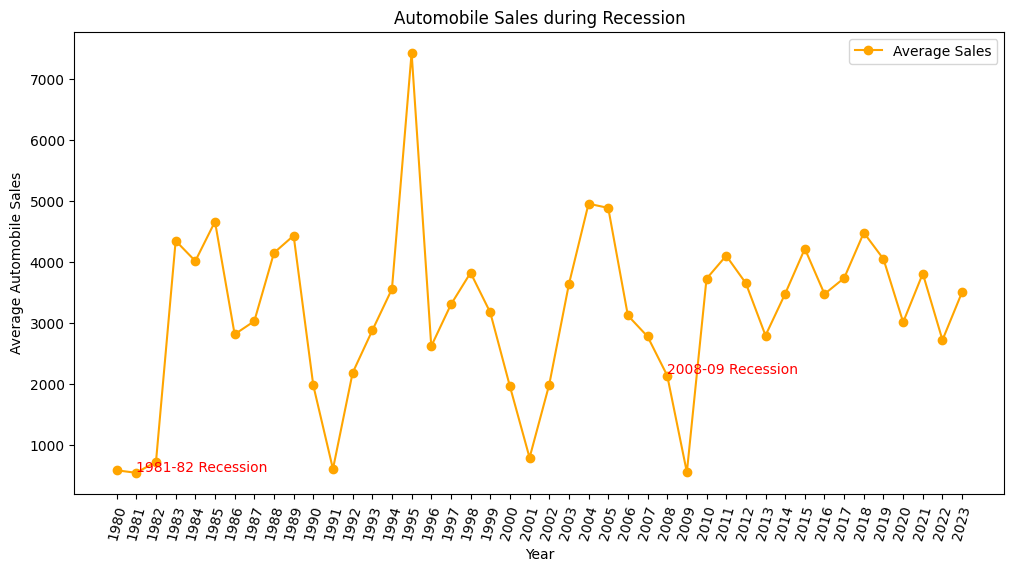

In [ ]:
# Task 1.1

# Step 1: Group by Year and calculate average Automobile_Sales
df_line = df.groupby('Year')['Automobile_Sales'].mean()

# Step 2: Plot line chart
plt.figure(figsize=(12, 6))
df_line.plot(kind='line', marker='o', color='orange')

# Step 3: Show all years on x-axis
plt.xticks(list(range(1980, 2024)), rotation=75)

# Step 4: Labels and title
plt.xlabel('Year')
plt.ylabel('Average Automobile Sales')
plt.title('Automobile Sales during Recession')

# Step 5: Annotate recession periods (example: 1981-82 and 2008-09)
plt.text(1981, df_line.loc[1981]+30, '1981-82 Recession', color='red', fontsize=10)
plt.text(2008, df_line.loc[2008]+30, '2008-09 Recession', color='red', fontsize=10)

# Step 6: Optional legend
plt.legend(['Average Sales'])

# Step 7: Show plot
plt.show()

TASK 1.2: How do trends in advertising expenditure correlate with automobile sales during non-recession periods, and what insights can be derived from this relationship

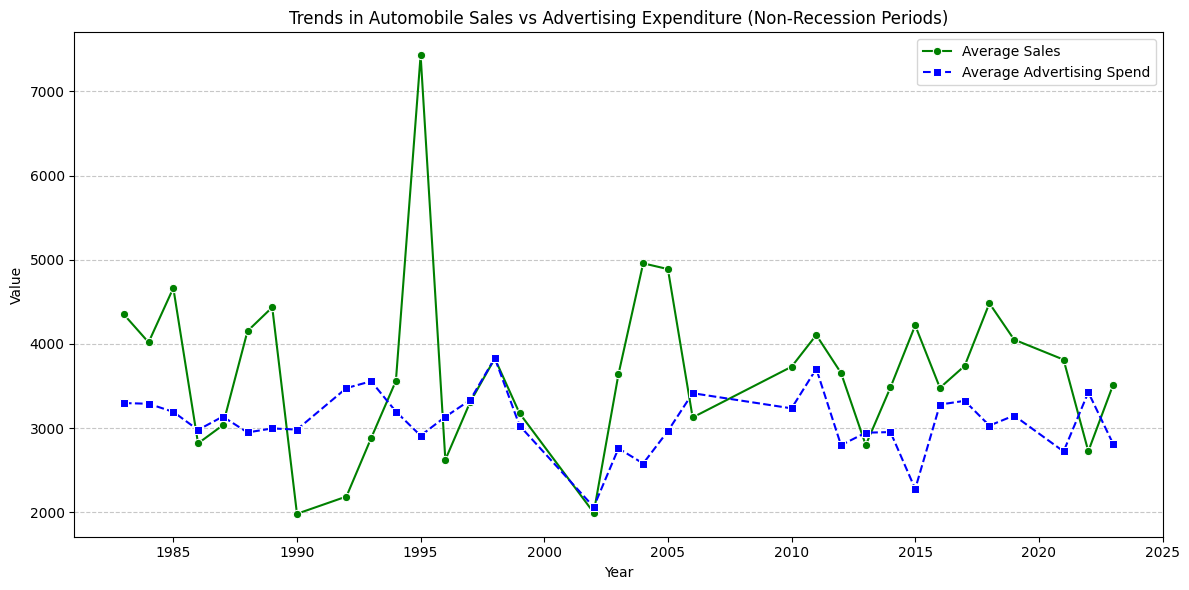

In [ ]:
# Task 1.2

# Step 1: Filter for non-recession periods
df_non_rec = df[df['Recession'] == 0]

# Step 2: Aggregate average sales and advertising expenditure by year
df_trends = df_non_rec.groupby('Year', as_index=False).agg(
    Avg_Sales=('Automobile_Sales', 'mean'),
    Avg_Ad_Spend=('Advertising_Expenditure', 'mean')
)

# Step 3: Plot trends using seaborn
plt.figure(figsize=(12, 6))

# Average automobile sales (solid green line with circular markers)
sns.lineplot(data=df_trends, x='Year', y='Avg_Sales', marker='o', linestyle='-', color='green', label='Average Sales')

# Average advertising expenditure (dashed blue line with square markers)
sns.lineplot(data=df_trends, x='Year', y='Avg_Ad_Spend', marker='s', linestyle='--', color='blue', label='Average Advertising Spend')

# Step 4: Add labels, title, legend, and grid
plt.xlabel('Year')
plt.ylabel('Value')
plt.title('Trends in Automobile Sales vs Advertising Expenditure (Non-Recession Periods)')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Step 5: Show plot
plt.tight_layout()
plt.show()

Inference: The graph indicates that during non-recession periods, advertising expenditure generally shows a steadier, more gradual trend compared to automobile sales, which fluctuate more noticeably year to year. While periods of higher advertising spending sometimes coincide with increases in sales, the alignment is not consistent, suggesting that other factors such as consumer confidence, seasonal effects or overall economic conditions and also significantly influence automobile sales. Overall, the correlation between advertising and sales appears moderate and variable over time, rather than perfectly linear.

TASK 1.3: Use the functionality of Seaborn Library to create a visualization to compare the sales trend per vehicle type for a recession period with a non-recession period.

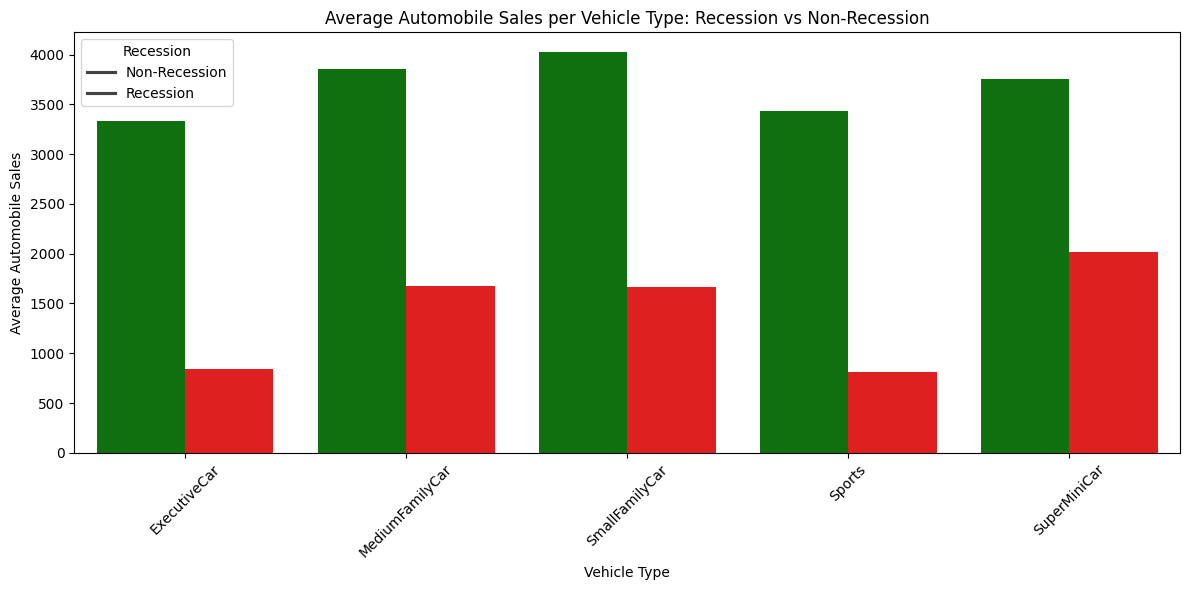

In [ ]:
# Task 1.3

# Step 1: Group by Recession and Vehicle_Type to calculate average sales
new_df = df.groupby(['Recession','Vehicle_Type'])['Automobile_Sales'].mean().reset_index()

# Step 2: Create the bar chart using Seaborn
plt.figure(figsize=(12,6))
sns.barplot(x='Vehicle_Type', y='Automobile_Sales', hue='Recession', data=new_df, palette=['green','red'])

# Step 3: Labels and title
plt.xlabel('Vehicle Type')
plt.ylabel('Average Automobile Sales')
plt.title('Average Automobile Sales per Vehicle Type: Recession vs Non-Recession')

# Step 4: Customize x-axis tick labels
plt.xticks(rotation=45)

# Step 5: Customize legend
plt.legend(title='Recession', labels=['Non-Recession', 'Recession'])

# Step 6: Show plot
plt.tight_layout()
plt.show()

Now you want to compare the sales of different vehicle types during a recession and a non-recession period


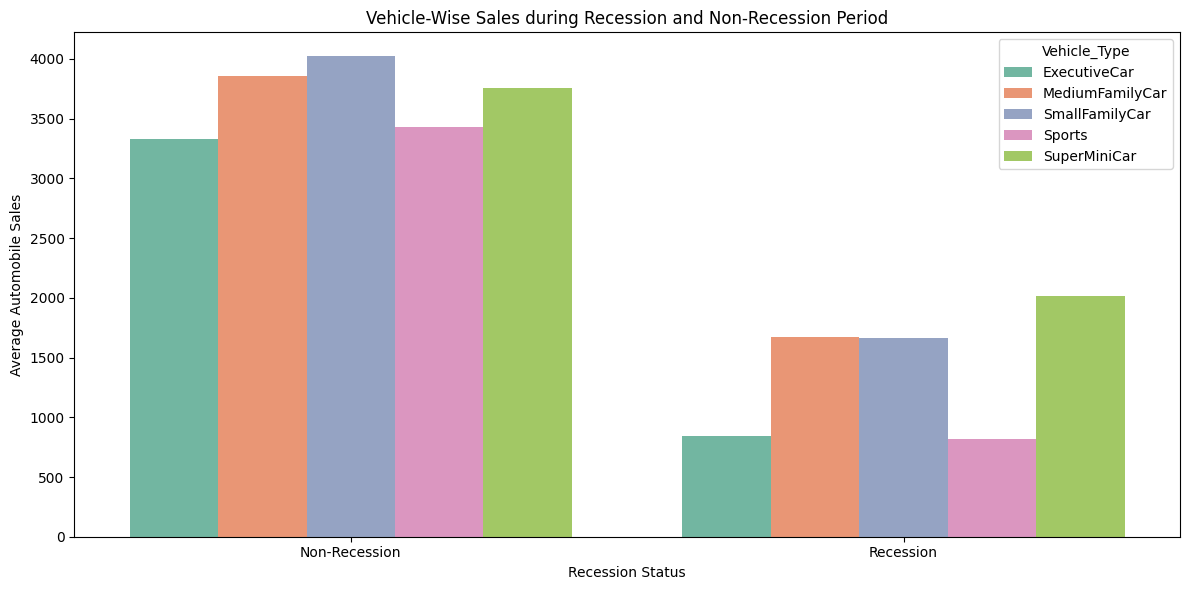

In [ ]:
# Step 1: Group by Recession and Vehicle_Type to calculate average Automobile_Sales
grouped_df = df.groupby(['Recession','Vehicle_Type'])['Automobile_Sales'].mean().reset_index()

# Step 2: Create the grouped bar chart using Seaborn
plt.figure(figsize=(12, 6))
sns.barplot(x='Recession', y='Automobile_Sales', hue='Vehicle_Type', data=grouped_df, palette='Set2')

# Step 3: Customize x-axis labels for clarity
plt.xticks(ticks=[0, 1], labels=['Non-Recession', 'Recession'])

# Step 4: Labels and title
plt.xlabel('Recession Status')
plt.ylabel('Average Automobile Sales')
plt.title('Vehicle-Wise Sales during Recession and Non-Recession Period')

# Step 5: Show plot
plt.tight_layout()
plt.show()

Inference:
The plot indicates that overall automobile sales decline noticeably during recession periods. Among the different vehicle types, Executive Cars and Sports Cars are the most affected, showing the largest drops in sales compared to other categories.

TASK 1.4: Use sub plotting to compare the variations in GDP during recession and non-recession period by developing line plots for each period.

Note- You want to find more insights from the data to understand the reason.
Plot a two line charts using subplotting to answer:-

How did the GDP vary over time during recession and non-recession periods?

Make use of add_subplot() from Matplotlib for this comparision.

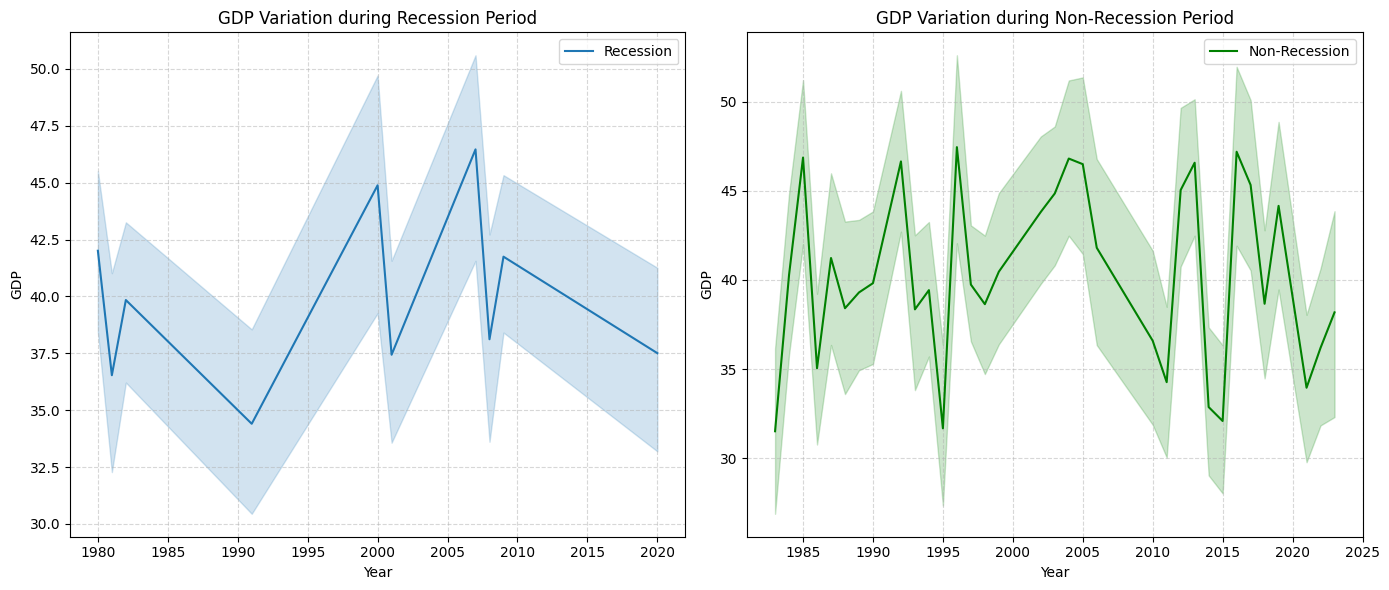

In [ ]:
# Task 1.4

# Step 1: Create separate dataframes for recession and non-recession periods
rec_data = df[df['Recession'] == 1]
non_rec_data = df[df['Recession'] == 0]

# Step 2: Using add_subplot() for side-by-side comparison
fig = plt.figure(figsize=(14,6))

# Subplot 1: GDP during recession
ax0 = fig.add_subplot(1, 2, 1)  # 1 row, 2 columns, first plot
sns.lineplot(x='Year', y='GDP', data=rec_data, label='Recession', ax=ax0)
ax0.set_xlabel('Year')
ax0.set_ylabel('GDP')
ax0.set_title('GDP Variation during Recession Period')
ax0.grid(True, linestyle='--', alpha=0.5)

# Subplot 2: GDP during non-recession
ax1 = fig.add_subplot(1, 2, 2)  # 1 row, 2 columns, second plot
sns.lineplot(x='Year', y='GDP', data=non_rec_data, label='Non-Recession', ax=ax1, color='green')
ax1.set_xlabel('Year')
ax1.set_ylabel('GDP')
ax1.set_title('GDP Variation during Non-Recession Period')
ax1.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

The plot shows that during recession periods, GDP is generally lower and exhibits greater volatility, reflecting significant fluctuations and economic uncertainty. In contrast, non-recession periods display a relatively higher GDP level with more stability, although some variability still exists.

TASK 1.5: Develop a Bubble plot for displaying the impact of seasonality on Automobile Sales.


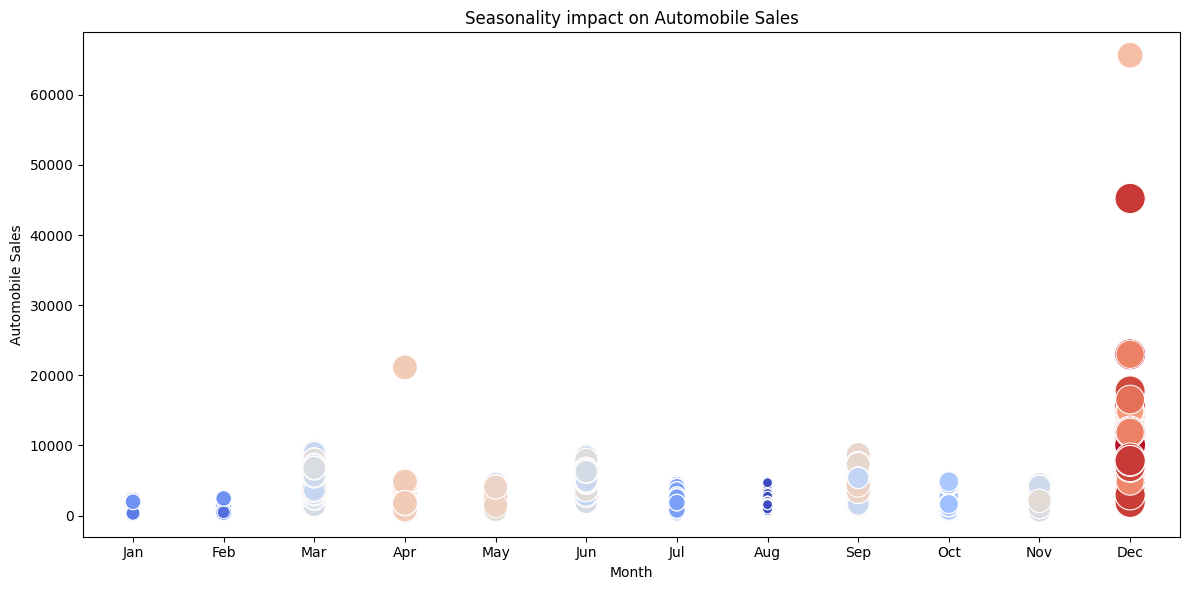

In [ ]:
# Task 1.5
# Step 1: Filter for non-recession periods
non_rec_data = df[df['Recession'] == 0]

# Step 2: Use Seasonality_Weight for bubble size
size = non_rec_data['Seasonality_Weight'] * 300  # scaling for better visibility

# Step 3: Create bubble plot
plt.figure(figsize=(12,6))
sns.scatterplot(data=non_rec_data, x='Month', y='Automobile_Sales',
                size=size, hue='Seasonality_Weight', palette='coolwarm', legend=False, sizes=(50, 500))

# Step 4: Labels and title
plt.xlabel('Month')
plt.ylabel('Automobile Sales')
plt.title('Seasonality impact on Automobile Sales')

# Step 5: Show plot
plt.tight_layout()
plt.show()

Inference:
From this plot, we can observe that seasonality generally has limited impact on overall sales but there are clear peaks in April and December, indicating higher sales during these months, likely due to holiday promotions and year-end purchases.
OR
From this plot, it is evident that seasonality has not affected on the overall sales. However, there is a drastic raise in sales in the month of April and December

TASK 1.6: Use the functionality of Matplotlib to develop a scatter plot to identify the relationship between consumer confidence and automobile sales during recessions.

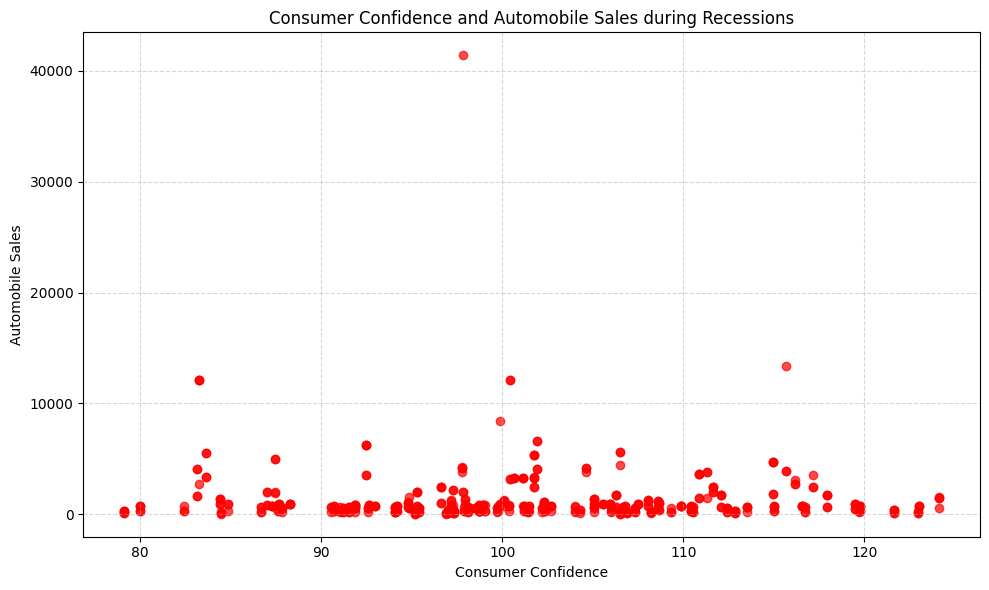

In [ ]:
# Task 1.6

# Step 1: Filter data for recession periods
rec_data = df[df['Recession'] == 1]

# Step 2: Create scatter plot
plt.figure(figsize=(10,6))
plt.scatter(rec_data['Consumer_Confidence'], rec_data['Automobile_Sales'], color='red', alpha=0.7)

# Step 3: Labels and title
plt.xlabel('Consumer Confidence')
plt.ylabel('Automobile Sales')
plt.title('Consumer Confidence and Automobile Sales during Recessions')

# Step 4: Optional grid for better readability
plt.grid(True, linestyle='--', alpha=0.5)

# Step 5: Show plot
plt.tight_layout()
plt.show()

From this scatter plot, it is evident that lower consumer confidence generally coincides with lower automobile sales during recessions, suggesting that consumer sentiment strongly influences purchasing behavior during economic downturns.
OR

The graphs indicate that during recessions, higher consumer confidence tends to boost automobile sales, while higher vehicle prices generally correspond to lower sales. This highlights the strong influence of both consumer sentiment and affordability on purchasing decisions during economic downturns.

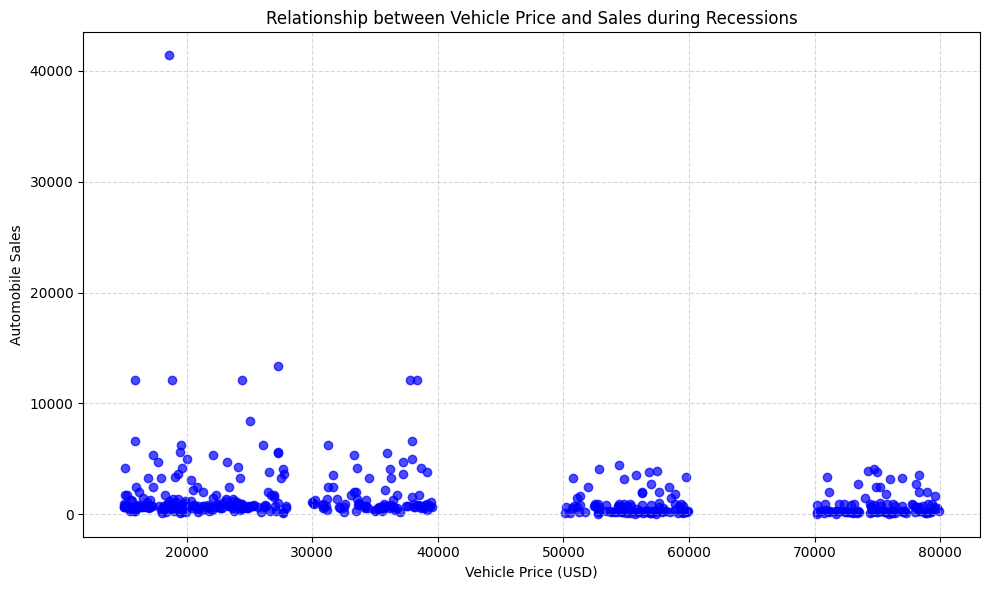

In [ ]:

# Step 1: Filter data for recession periods
rec_data = df[df['Recession'] == 1]

# Step 2: Create scatter plot for Price vs Automobile Sales
plt.figure(figsize=(10,6))
plt.scatter(rec_data['Price'], rec_data['Automobile_Sales'], color='blue', alpha=0.7)

# Step 3: Labels and title
plt.xlabel('Vehicle Price (USD)')
plt.ylabel('Automobile Sales')
plt.title('Relationship between Vehicle Price and Sales during Recessions')

# Step 4: Optional grid
plt.grid(True, linestyle='--', alpha=0.5)

# Step 5: Show plot
plt.tight_layout()
plt.show()

Inference:

The scatter plots show that:

Higher consumer confidence during recessions is generally associated with higher automobile sales, indicating that sentiment strongly affects buying behavior.

Higher vehicle prices tend to correspond with lower sales, highlighting that affordability becomes a critical factor during economic downturns.

Together, these plots emphasize that both consumer sentiment and price sensitivity strongly influence automobile purchases during recessions.

TASK 1.7: Create a pie chart to display the portion of advertising expenditure of XYZAutomotives during recession and non-recession periods.

How did the advertising expenditure of XYZAutomotives change during recession and non-recession periods?

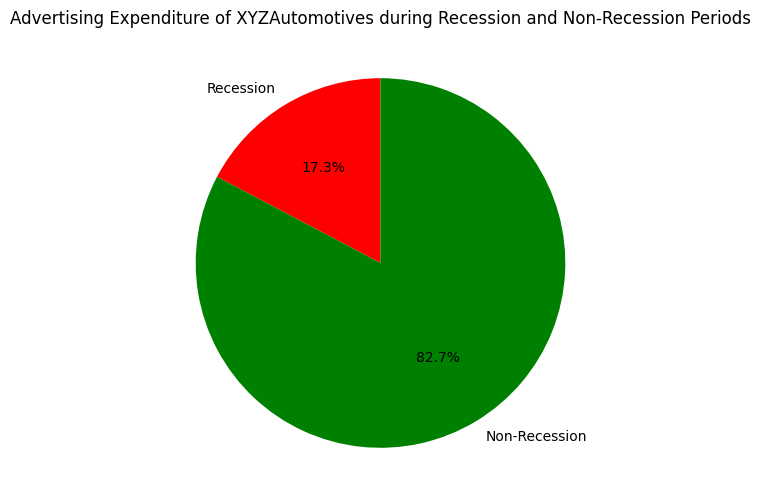

In [ ]:
# Task 1.7

# Step 1: Filter data for recession and non-recession periods
Rdata = df[df['Recession'] == 1]
NRdata = df[df['Recession'] == 0]

# Step 2: Calculate total advertising expenditure
RAtotal = Rdata['Advertising_Expenditure'].sum()
NRAtotal = NRdata['Advertising_Expenditure'].sum()

# Step 3: Create pie chart
plt.figure(figsize=(8,6))
labels = ['Recession', 'Non-Recession']
sizes = [RAtotal, NRAtotal]
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=['red','green'])
plt.title('Advertising Expenditure of XYZAutomotives during Recession and Non-Recession Periods')
plt.show()

The pie chart shows that XYZAutomotives spends significantly more on advertising during non-recession periods than during recessions. This suggests that the company may scale back marketing efforts during economic downturns, possibly due to budget constraints or lower expected returns on advertising.

OR

It seems XYZAutomotives has been spending much more on the advertisements during non-recession periods as compared to during recession times. Fair enough!


TASK 1.8: Develop a pie chart to display the total Advertisement expenditure for each vehicle type during recession period.

Can we observe the share of each vehicle type in total expenditure during recessions?

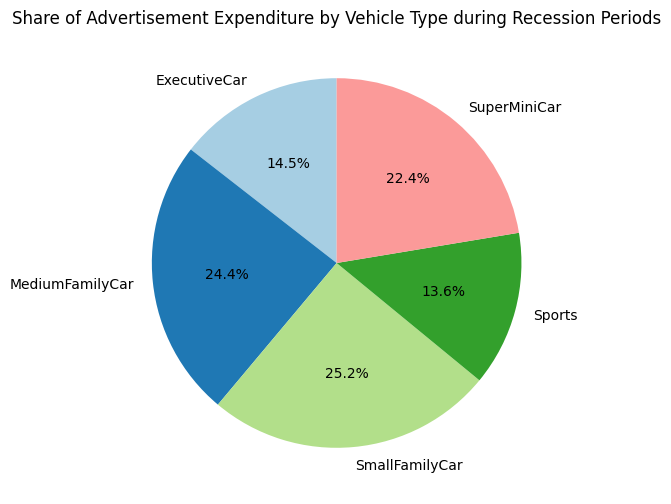

In [ ]:
# Task 1.8
# Step 1: Filter data for recession period
Rdata = df[df['Recession'] == 1]

# Step 2: Calculate total advertising expenditure by vehicle type during recessions
VTexpenditure = Rdata.groupby('Vehicle_Type')['Advertising_Expenditure'].sum()

# Step 3: Create pie chart
plt.figure(figsize=(8,6))
labels = VTexpenditure.index
sizes = VTexpenditure.values
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=plt.cm.Paired.colors)
plt.title('Share of Advertisement Expenditure by Vehicle Type during Recession Periods')
plt.show()

Inference

The pie chart shows that during recessions, advertising expenditure is primarily focused on lower-priced vehicle categories, likely targeting more affordable options. This strategy makes sense, as consumers tend to be more price-sensitive during economic downturns, making it a wise allocation of marketing resources.

OR

During recession the advertisements were mostly focused on low price range vehicle. A wise decision!

TASK 1.9: Develop a lineplot to analyse the effect of the unemployment rate on vehicle type and sales during the Recession Period.

Analyze the effect of the unemployment rate on vehicle type and sales during the Recession Period

/tmp/ipykernel_803/1606204852.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rec_data['Unemployment_Rate_Rounded'] = rec_data['unemployment_rate'].round(1)


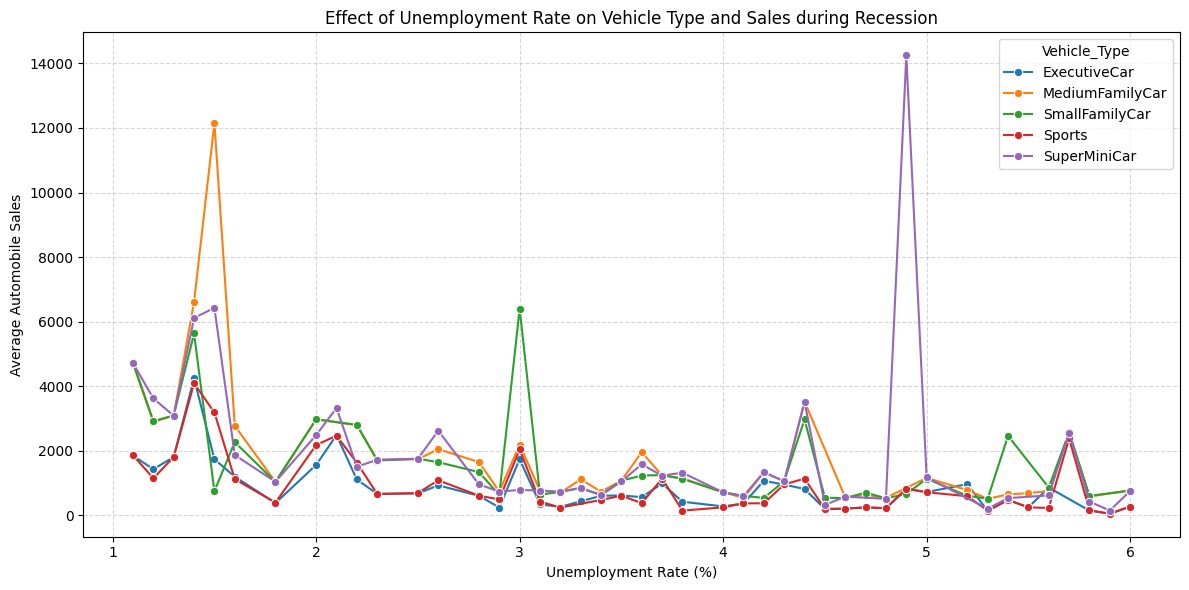

In [ ]:
# Task 1.9

# Step 1: Filter data for recession period
rec_data = df[df['Recession'] == 1]

# Step 2: Aggregate average sales by Vehicle_Type and Unemployment_Rate
# Optional: you can group by unemployment rate rounded to 1 decimal for clearer line trends
rec_data['Unemployment_Rate_Rounded'] = rec_data['unemployment_rate'].round(1)
sales_by_unemp = rec_data.groupby(['Unemployment_Rate_Rounded', 'Vehicle_Type'])['Automobile_Sales'].mean().reset_index()

# Step 3: Create lineplot
plt.figure(figsize=(12,6))
sns.lineplot(data=sales_by_unemp, x='Unemployment_Rate_Rounded', y='Automobile_Sales', hue='Vehicle_Type', marker='o')

# Step 4: Labels and title
plt.xlabel('Unemployment Rate (%)')
plt.ylabel('Average Automobile Sales')
plt.title('Effect of Unemployment Rate on Vehicle Type and Sales during Recession')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Inference:

The plot shows that automobile sales decline as unemployment rates rise during a recession, with sharp drops beyond 3%. SuperMiniCars, SmallFamilyCars and MediumFamilyCars exhibit high volatility, reflecting their sensitivity to economic uncertainty and changing consumer priorities.

OR


The plot shows that automobile sales decline as unemployment rates rise during recession periods, with particularly sharp drops beyond ~3%. Among vehicle types, SuperMiniCars, SmallFamilyCars and MediumFamilyCars exhibit high volatility, indicating they are most sensitive to economic uncertainty and shifts in consumer priorities during downturns